# Lab 5: Supervised Learning Regression

## Imports

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

## Exercise 1: Dataset Understanding and Preprocessing

### 1. Load the dataset and display .head(), .info(), and .describe().

In [2]:
df = pd.read_csv("datasets/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
df.describe(include="object")

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


### 2. Identify categorical and numerical features.

In [6]:
cat_cols = ["sex", "smoker", "region"]
num_cols = ["age", "bmi", "children", "charges"]

### 3. Handle missing values if any.

In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### 4. Encode categorical features using:
1. Label Encoding
2. One-Hot Encoding

In [8]:
df = df.copy()
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [9]:
df = pd.get_dummies(
    df,
    columns=['region'],
    drop_first=True
)
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)
df.head()

,age,sex,bmi,children,smoker,charges,region_1,region_2,region_3
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


### 5. Normalize/standardize numerical features.

In [10]:
scaler = StandardScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

df.head()

,age,sex,bmi,children,smoker,charges,region_1,region_2,region_3
0,-1.438764,0,-0.453320,-0.908614,1,0.298584,0,0,1
1,-1.509965,1,0.509621,-0.078767,0,-0.953689,0,1,0
2,-0.797954,1,0.383307,1.580926,0,-0.728675,0,1,0
3,-0.441948,1,-1.305531,-0.908614,0,0.719843,1,0,0
4,-0.513149,1,-0.292556,-0.908614,0,-0.776802,1,0,0


### 6. Split the dataset into training and testing sets (80:20).

In [11]:
X = df.drop("charges", axis=1)
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1070, 8), (268, 8), (1070,), (268,))

## Exercise 2: Apply Machine Learning Regression Models

***Apply the following regression models to predict charges:***  
1. Simple Linear Regression (using bmi only)
2. Multiple Linear Regression (all features)
3. Polynomial Regression (degree 2 and 3)
4. Ridge Regression (with tuning alpha)
5. Lasso Regression (with tuning alpha)
6. Decision Tree Regressor

***For each model:***  
1. Train the model
2. Predict on test data
3. Evaluate and record:  
    1. MAE
    2. MSE
    3. RMSE
    4. R² Score  
4. Create scatter plot of Actual vs Predicted values  

In [12]:
all_metrics = []

def get_metrics(y_train, y_train_pred, y_test, y_test_pred):
    return {
        "Train MAE": mean_absolute_error(y_train, y_train_pred),
        "Train MSE": mean_squared_error(y_train, y_train_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "Train R2": r2_score(y_train, y_train_pred),
        "Test MAE": mean_absolute_error(y_test, y_test_pred),
        "Test MSE": mean_squared_error(y_test, y_test_pred),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
        "Test R2": r2_score(y_test, y_test_pred)
    }

In [13]:
def plot_actual_vs_pred(y_true, y_pred, title):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             linestyle="--", color="red")
    plt.xlabel("Actual Charges")
    plt.ylabel("Predicted Charges")
    plt.title(title)
    plt.show()

### Simple Linear Regression (bmi only)

In [14]:
X_train_bmi = X_train[["bmi"]]
X_test_bmi = X_test[["bmi"]]

slr = LinearRegression()
slr.fit(X_train_bmi, y_train)

y_train_pred = slr.predict(X_train_bmi)
y_test_pred = slr.predict(X_test_bmi)

metrics = get_metrics(y_train, y_train_pred, y_test, y_test_pred)
metrics["Model"] = "Simple Linear Regression"

all_metrics.append(metrics)

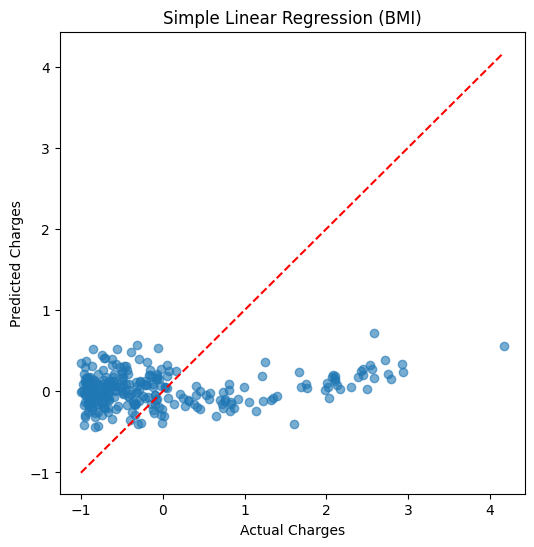

In [15]:
plot_actual_vs_pred(y_test, y_test_pred, "Simple Linear Regression (BMI)")

### Multiple Linear Regression (all features)

In [16]:
mlr = LinearRegression()
mlr.fit(X_train, y_train)

y_train_pred = mlr.predict(X_train)
y_test_pred = mlr.predict(X_test)

metrics = get_metrics(y_train, y_train_pred, y_test, y_test_pred)
metrics["Model"] = "Multiple Linear Regression"

all_metrics.append(metrics)

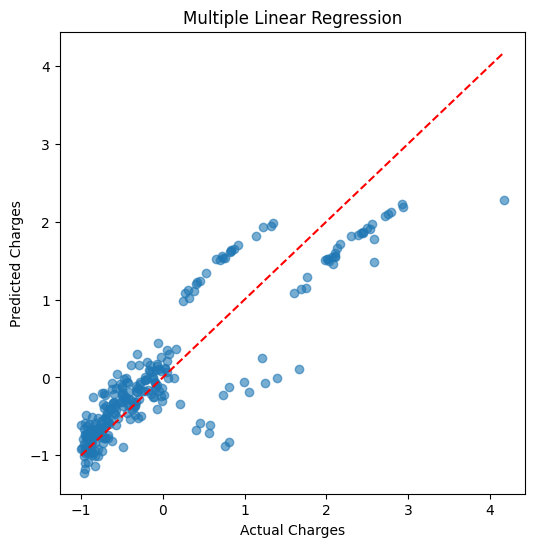

In [17]:
plot_actual_vs_pred(y_test, y_test_pred, "Multiple Linear Regression")

### Polynomial Regression (Degree 2)

In [18]:
poly2 = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly2 = poly2.fit_transform(X_train)
X_test_poly2 = poly2.transform(X_test)

poly_reg2 = LinearRegression()
poly_reg2.fit(X_train_poly2, y_train)

y_train_pred = poly_reg2.predict(X_train_poly2)
y_test_pred = poly_reg2.predict(X_test_poly2)

metrics = get_metrics(y_train, y_train_pred, y_test, y_test_pred)
metrics["Model"] = "Polynomial Regression (Degree 2)"

all_metrics.append(metrics)

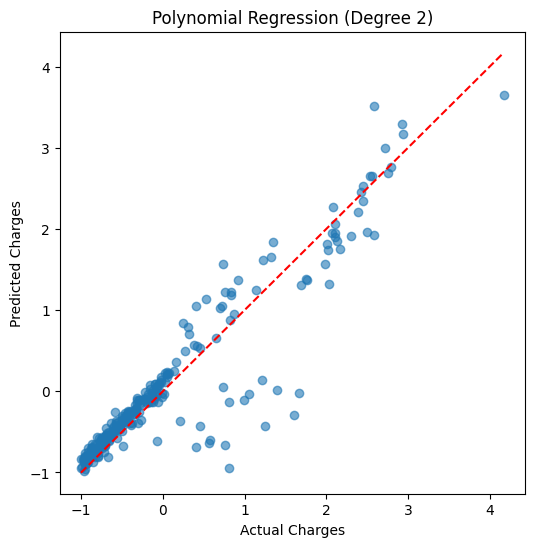

In [19]:
plot_actual_vs_pred(y_test, y_test_pred, "Polynomial Regression (Degree 2)")

### Polynomial Regression (Degree 3)

In [20]:
poly3 = PolynomialFeatures(degree=3, include_bias=False)

X_train_poly3 = poly3.fit_transform(X_train)
X_test_poly3 = poly3.transform(X_test)

poly_reg3 = LinearRegression()
poly_reg3.fit(X_train_poly3, y_train)

y_train_pred = poly_reg3.predict(X_train_poly3)
y_test_pred = poly_reg3.predict(X_test_poly3)

metrics = get_metrics(y_train, y_train_pred, y_test, y_test_pred)
metrics["Model"] = "Polynomial Regression (Degree 3)"

all_metrics.append(metrics)

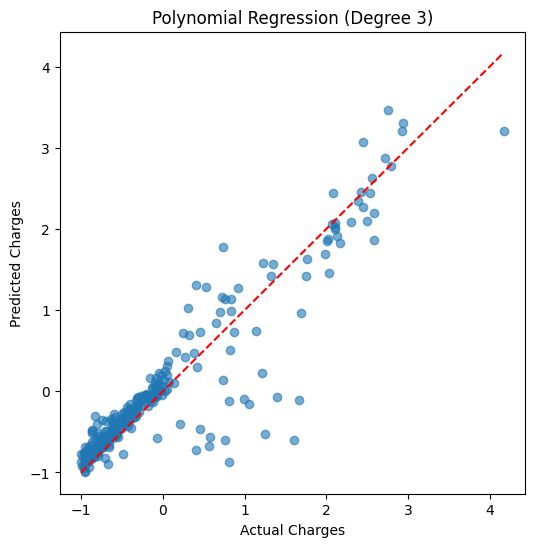

In [21]:
plot_actual_vs_pred(y_test, y_test_pred, "Polynomial Regression (Degree 3)")

### Ridge Regression (alpha tuning)

In [22]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_train_pred = ridge.predict(X_train)
y_test_pred = ridge.predict(X_test)

metrics = get_metrics(y_train, y_train_pred, y_test, y_test_pred)
metrics["Model"] = "Ridge Regression"

all_metrics.append(metrics)

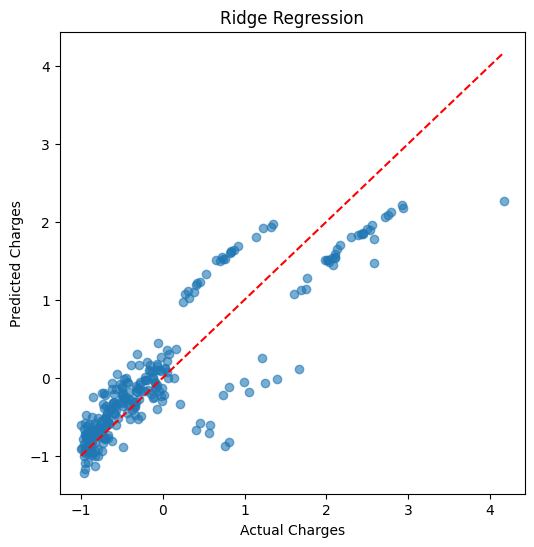

In [23]:
plot_actual_vs_pred(y_test, y_test_pred, "Ridge Regression")

### Lasso Regression (alpha tuning)

In [24]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)

y_train_pred = lasso.predict(X_train)
y_test_pred = lasso.predict(X_test)

metrics = get_metrics(y_train, y_train_pred, y_test, y_test_pred)
metrics["Model"] = "Lasso Regression"

all_metrics.append(metrics)

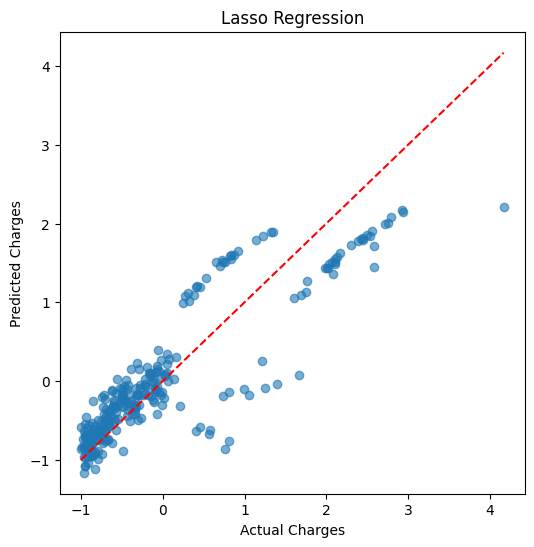

In [25]:
plot_actual_vs_pred(y_test, y_test_pred, "Lasso Regression")

### Decision Tree Regressor

In [26]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

metrics = get_metrics(y_train, y_train_pred, y_test, y_test_pred)
metrics["Model"] = "Decision Tree Regressor"

all_metrics.append(metrics)

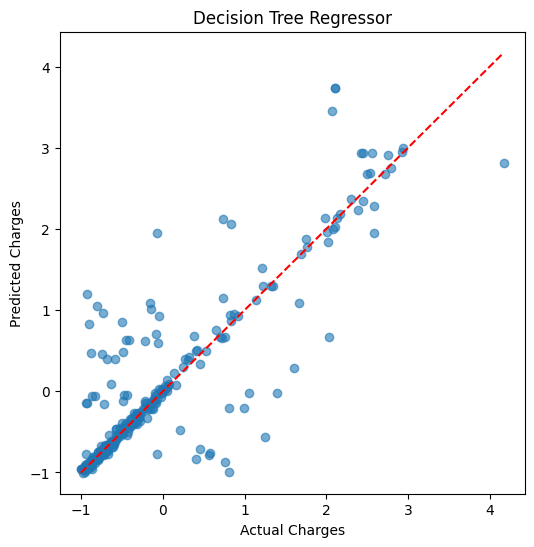

In [27]:
plot_actual_vs_pred(y_test, y_test_pred, "Decision Tree Regressor")

## Exercise 3: Artificial Neural Network (ANN) for Regression

### Step 1: ANN Model Design

Design a Feed-Forward Neural Network for regression with:
1. Input layer: number of neurons = number of features
2. Hidden layers: 1 or 2 hidden layers
3. Activation function:
    1. Hidden layer: ReLU
    2. Output layer: Linear activation
4. Loss function: Mean Squared Error (MSE)
5. Optimizer: Adam (default parameters)

In [28]:
n_features = X_train.shape[1]

model = Sequential([
    Dense(16, activation="relu", input_shape=(n_features,)),
    Dense(8, activation="relu"),
    Dense(1, activation="linear")
])

D:\python\python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Step 2: Model Training

1. Compile the ANN model
3. Use validation split (e.g., 10–20%)
4. Train for suitable epochs (e.g., 100)

In [29]:
model.compile(
    optimizer="adam",
    loss="mse"
)

In [30]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

### Step 3: Model Evaluation

1. Predict on test data

In [31]:
y_train_pred = model.predict(X_train, verbose=0)
y_test_pred = model.predict(X_test, verbose=0)

2. Compute:
    1. MAE
    2. MSE
    3. RMSE
    4. R² Score

In [32]:
metrics = get_metrics(y_train, y_train_pred, y_test, y_test_pred)
metrics["Model"] = "Artificial Neural Network (ANN)"

all_metrics.append(metrics)

In [33]:
all_metrics[-1]

{'Train MAE': 0.23988000691358094,
 'Train MSE': 0.14232404241704746,
 'Train RMSE': np.float64(0.3772585882614834),
 'Train R2': 0.8554975712866161,
 'Test MAE': 0.24220394613469728,
 'Test MSE': 0.14292204094170252,
 'Test RMSE': np.float64(0.37805031535723194),
 'Test R2': 0.8650926737291182,
 'Model': 'Artificial Neural Network (ANN)'}

3. Plot:
    1. Training vs Validation loss curve
    2. Actual vs Predicted scatter plot

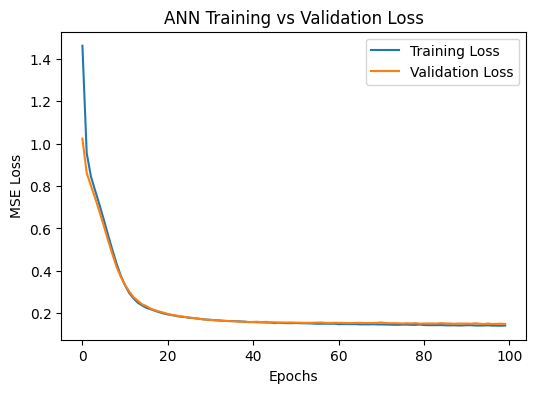

In [34]:
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("ANN Training vs Validation Loss")
plt.legend()
plt.show()

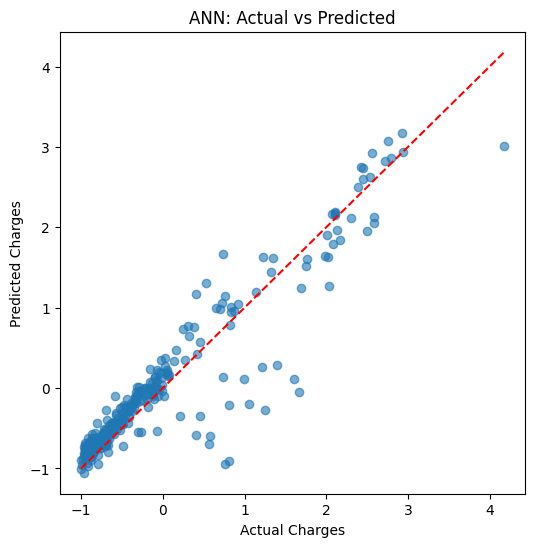

In [35]:
plot_actual_vs_pred(y_test, y_test_pred, "ANN: Actual vs Predicted")

## Exercise 4: Model Comparison – ML vs DL

### Step 1: Create Evaluation Tables

In [36]:
all_metrics_df = pd.DataFrame(all_metrics).set_index("Model")

#### Table A: Training Data

In [37]:
all_metrics_df[[col for col in all_metrics_df.columns if "Train" in col]]

,Train MAE,Train MSE,Train RMSE,Train R2
Model,,,,
Simple Linear Regression,0.749078,0.946578,0.972922,0.038934
Multiple Linear Regression,0.347630,0.254381,0.504362,0.741726
Polynomial Regression (Degree 2),0.238912,0.155798,0.394713,0.841817
Polynomial Regression (Degree 3),0.230704,0.142861,0.377970,0.854952
Ridge Regression,0.348393,0.254402,0.504382,0.741705
Lasso Regression,0.350395,0.255908,0.505874,0.740175
Decision Tree Regressor,0.002443,0.001667,0.040825,0.998308
Artificial Neural Network (ANN),0.239880,0.142324,0.377259,0.855498


#### Table B: Testing Data

In [38]:
all_metrics_df[[col for col in all_metrics_df.columns if "Test" in col]]

,Test MAE,Test MSE,Test RMSE,Test R2
Model,,,,
Simple Linear Regression,0.808283,1.017348,1.008637,0.039702
Multiple Linear Regression,0.345397,0.229264,0.478815,0.783593
Polynomial Regression (Degree 2),0.225476,0.141343,0.375956,0.866583
Polynomial Regression (Degree 3),0.242693,0.160351,0.400438,0.848641
Ridge Regression,0.346387,0.229594,0.479160,0.783281
Lasso Regression,0.351573,0.234397,0.484146,0.778747
Decision Tree Regressor,0.263548,0.294369,0.542558,0.722138
Artificial Neural Network (ANN),0.242204,0.142922,0.378050,0.865093


## Exercise 5: Analysis and Interpretation

### 1. Compare ML models vs ANN performance

From the testing metrics:  

1. Simple Linear Regression performs poorly (low R2 ~ 0.04), showing that BMI alone is insufficient to explain insurance charges.
2. Multiple Linear Regression, Ridge, and Lasso perform similarly with moderate R2 (~0.77–0.78), indicating linear relationships capture only part of the data pattern.
3. Polynomial Regression (Degree 2 & 3) improves performance significantly (R2 ~ 0.85–0.86), showing the presence of non-linear relationships.
4. Decision Tree Regressor performs extremely well on training data (R2 ~ 0.998) but drops sharply on test data (R2 ~ 0.72).
5. Artificial Neural Network (ANN) achieves the best overall generalization, with high and consistent R2 on both training ~0.85 and testing ~0.86.

### 2. Identify overfitting and underfitting

Underfitting
1. Simple Linear Regression
2. Multiple Linear Regression

Overfitting
1. Decision Tree Regressor

Well-Balanced Models
1. Polynomial Regression (Degree 2 & 3)
2. ANN

### 3. Discuss impact of

#### 1.  Model complexity

Increasing complexity from Linear to Polynomial to ANN improves performance.  
  
However:  
Too little complexity leads to underfitting  
Too much complexity (Decision Tree) leads to overfitting  

ANN achieves controlled complexity through:  
Layered structure  
Gradient-based optimization   
Implicit regularization via training dynamics  

#### 2.  Regularization

Ridge Regression
1. Shrinks coefficients
2. Reduces overfitting
3. Performs slightly better than plain linear regression

Lasso Regression
1. Performs feature selection
2. Slightly lower R² than Ridge

Regularization improves stability, but linear models still struggle with complex non-linear patterns.

#### 3.  Number of epochs (ANN)

1. With 100 epochs, ANN shows:
    1. Stable training and validation loss
    2. No major divergence so we are not overfitting
2. Too few epochs we risk underfitting
3. Too many epochs we have a risk of overfitting
4. Proper epoch selection helps ANN learn non-linear patterns efficiently.

### 4.  Explain why ANN can model non-linear relationships better

ANN Applies multiple non-linear transformations ReLU (or tanh/leaky relu etc.) activations. which helps the model learn non linear relationships if we have no non linarity and only have a linear activeation our model can only learn linear relationships since there is no non linearity in our model.

### 5.  Comment on computational cost vs performance

| Model                  | Cost     | Performance |
| ---------------------- | -------- | ----------- |
| Linear / Ridge / Lasso | Very Low | Moderate    |
| Polynomial Regression  | Medium   | High        |
| Decision Tree          | Low      | Unstable    |
| ANN                    | High     | Best        |

## Knowledge Check Questions (Answer any 5)

1. Why is linear activation used in the output layer of ANN for regression?

Linear activation is used for ANN Regression because we are doing a regression task and not trying to predicts probablities for categories.

2. How does ANN differ from Polynomial Regression?

ANN differs from poly regression in a way that ANN can learn any complex non linear relationship while in poly regression we have to predefine the relationship as we did for degree 2 and 3. 

3. What role does optimizer play in ANN training?

the roal of the optimizer is to find the best weights for given data to get the highest accurecy.

4. Why does ANN require feature scaling?

ANN requires featur scaling because having huge differences in the feature values leads to unstable gradient which leads to slow or failed convergence. feature scaling improves the convergence speed and stability.

5. Compare overfitting behavior of Decision Tree and ANN.

Decision trees without tuning hyper parameters leads to overfitting since the tree grows and grows and memorizes the traning data insted of generalizing. while in ANN can also over fit if we have many hidden layers and thousands of nurons in this i tested hidden layers with 320, 160, 80, 1 nurons and it was giving r2 score of 0.93 on train data and around 0.87 on testing data so it was over fitting. so with proper tuning both models doesn't lead to the overfitting.

6. When would ML regression models be preferred over ANN?

when we know that the task we are doing is simple and has linear relationships, features are normally distributed, dataset is small, or we don't have much computational resources. it mostly depends on the task as in this task we can get a high acc even with ml models after proper tuning so we don't need to use deep learning here.

7. How does batch size affect ANN training?

batch size determines how many samples are used to update the gradient. so if we have a batch size of 1 only 1 sample is used to update the gradient which causes the weights to bounce around a lot since it tries to fit one sample at a time and on the other hand if we use all the samples to update the gradient it becomes computationally expensive and can lead to low generalization but is gives a smoother gradients and batch size of somewhere in between is best of both world gradient us not as smooth as using all the samples but it will be way better then using one sample and also it reduces the computational costs.